# Стоит ли сегодня гулять?

## Задача

Дан размеченный датасет с описанием погоды: температура, солнечность, скорость ветра, наличие дождь. Отвечаем на вопрос "можно ли идти гулять?".

## Реализация

### Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

import tensorflow as tf
from tensorflow import keras

import torch
import torch.nn as nn
import torch.optim as optim

### Загрузка данных и первичный анализ

In [ ]:
weather_df = pd.read_csv('/weather.csv', sep=";")
weather_df

,Солнечно,Температура воздуха,Скорость ветра,Дождь,Гулять?
0,0,13,0,0,1
1,0,7,6,0,0
2,0,9,10,0,0
3,0,19,6,1,0
4,0,17,8,1,0
...,...,...,...,...,...
295,1,14,9,1,0
296,0,15,2,0,1
297,0,12,0,0,1
298,1,20,0,0,1


In [ ]:
# Переименуем признаки
mapper = {
    "Солнечно": "is_sunny",
    "Температура воздуха": "temperature",
    "Скорость ветра": "wind_speed",
    "Дождь": "is_rainy",
    "Гулять?": "walk"
}
weather_df.columns = pd.Index(map(lambda col_name: mapper[col_name] if col_name in mapper else col_name, weather_df.columns))
weather_df

,is_sunny,temperature,wind_speed,is_rainy,walk
0,0,13,0,0,1
1,0,7,6,0,0
2,0,9,10,0,0
3,0,19,6,1,0
4,0,17,8,1,0
...,...,...,...,...,...
295,1,14,9,1,0
296,0,15,2,0,1
297,0,12,0,0,1
298,1,20,0,0,1


In [ ]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   is_sunny     300 non-null    int64
 1   temperature  300 non-null    int64
 2   wind_speed   300 non-null    int64
 3   is_rainy     300 non-null    int64
 4   walk         300 non-null    int64
dtypes: int64(5)
memory usage: 11.8 KB


In [ ]:
weather_df.describe()

,is_sunny,temperature,wind_speed,is_rainy,walk
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.516667,16.023333,5.040000,0.396667,0.603333
std,0.500557,6.411955,3.075157,0.490023,0.490023
min,0.000000,5.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,2.750000,0.000000,0.000000
50%,1.000000,16.000000,5.000000,0.000000,1.000000
75%,1.000000,22.000000,8.000000,1.000000,1.000000
max,1.000000,26.000000,10.000000,1.000000,1.000000


In [ ]:
train_features = weather_df.iloc[:, :-1]
target_feature = weather_df.iloc[:, -1]
target_col = target_feature.name

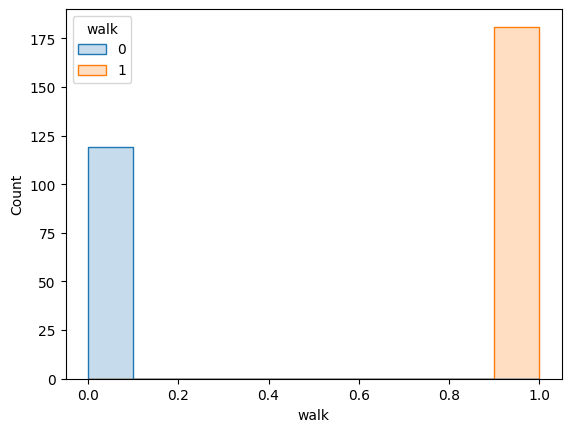

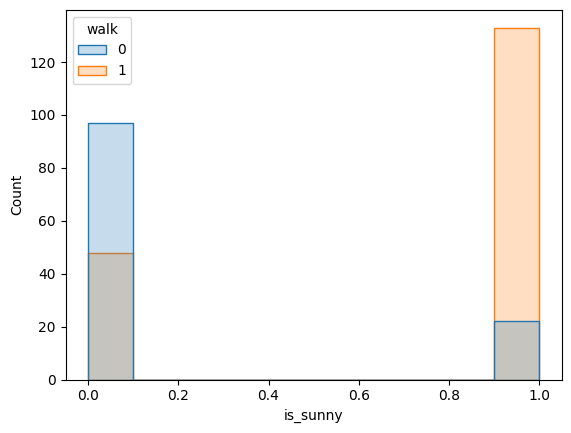

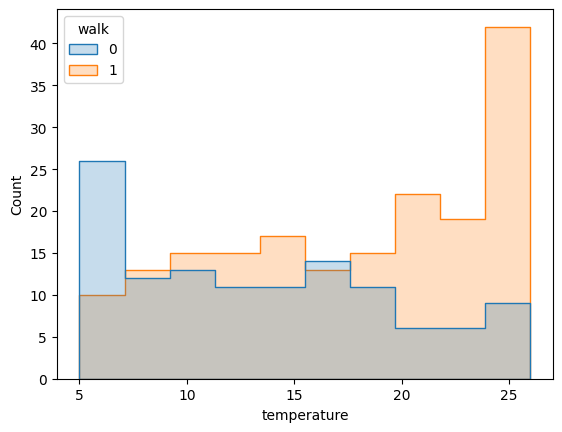

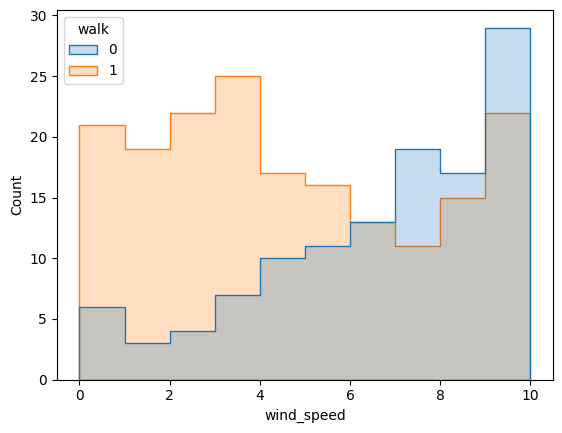

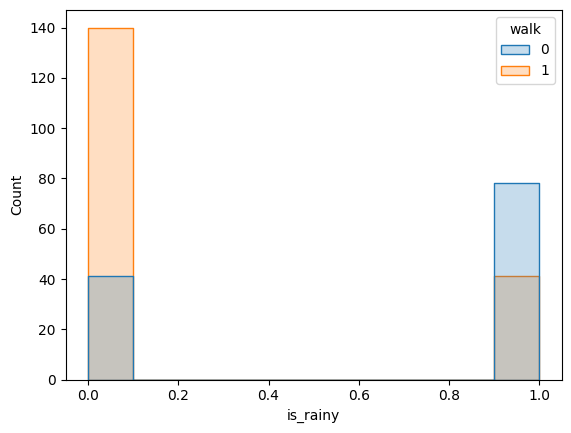

In [ ]:
sns.histplot(data=weather_df, x=target_feature.name, hue=target_feature.name, kde=False, element="step")
plt.show()

for col_name in train_features.columns:
  sns.histplot(data=weather_df, x=col_name, hue=target_feature.name, kde=False, element="step")
  plt.show()

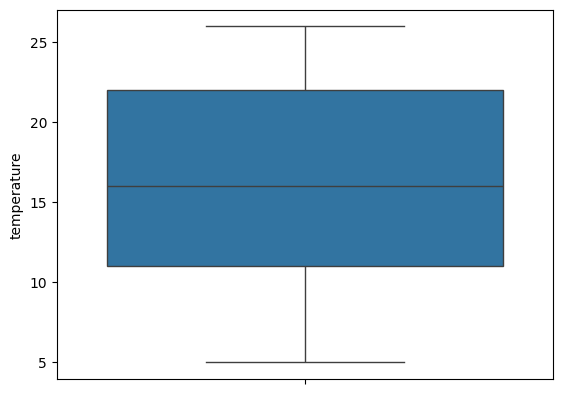

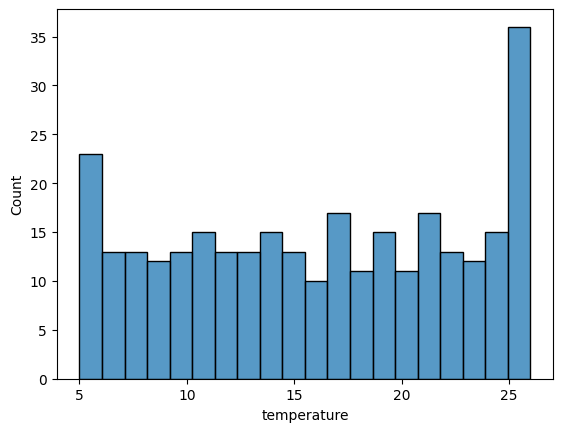

In [ ]:
sns.boxplot(weather_df["temperature"])
plt.show()
sns.histplot(weather_df["temperature"], bins=20)
plt.show()

### Предобработка данных

In [ ]:
scaler = MinMaxScaler()

weather_df = pd.DataFrame(scaler.fit_transform(weather_df), columns=weather_df.columns)
weather_df[target_col] = weather_df[target_col].astype(int)

In [ ]:
weather_df.describe()

,is_sunny,temperature,wind_speed,is_rainy,walk
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.516667,0.524921,0.504000,0.396667,0.603333
std,0.500557,0.305331,0.307516,0.490023,0.490023
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.285714,0.275000,0.000000,0.000000
50%,1.000000,0.523810,0.500000,0.000000,1.000000
75%,1.000000,0.809524,0.800000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train_features, target_feature, test_size=0.2)

### Построение и обучение моделей

In [ ]:
neurons_on_hidden = [10, 5]

In [ ]:
def custom_evaluation(y_test, y_pred):
  print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
  print(f'Precision: {precision_score(y_test, y_pred)}')
  print(f'Recall: {recall_score(y_test, y_pred)}')
  print(f'F1: {f1_score(y_test, y_pred)}')

  fig, ax = plt.subplots(figsize=(4, 3))
  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Greens", ax=ax)
  ax.set_xlabel('Предсказанные')
  ax.set_ylabel('Истинные')
  ax.set_title('Матрица ошибок')
  plt.show()

#### Scikit learn

Accuracy: 0.9666666666666667
Precision: 1.0
Recall: 0.9393939393939394
F1: 0.96875


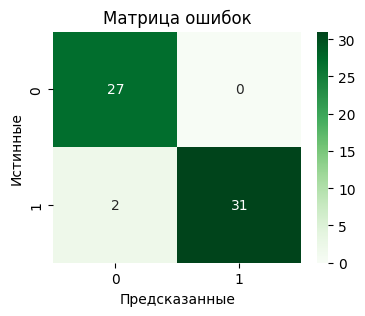

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=neurons_on_hidden, max_iter=1000)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
custom_evaluation(y_test, y_pred)

#### TensorFlow

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Accuracy: 0.95
Precision: 1.0
Recall: 0.9090909090909091
F1: 0.9523809523809523


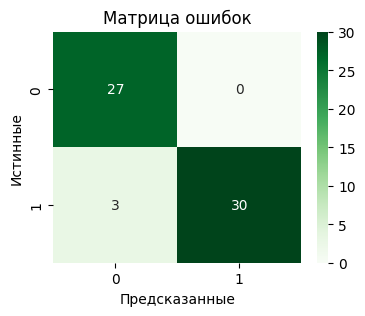

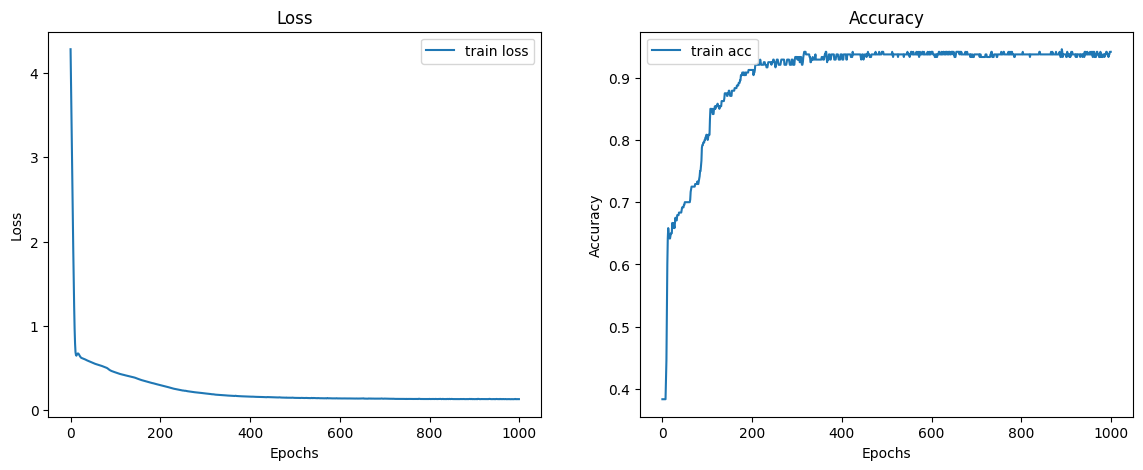

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(neurons_on_hidden[0], activation='relu'),
    keras.layers.Dense(neurons_on_hidden[1], activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_history = model.fit(X_train, y_train, epochs=1000, batch_size=100, verbose=0)

y_pred_proba = model.predict(X_test).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
custom_evaluation(y_test, y_pred)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(model_history.history['loss'], label='train loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_history.history['accuracy'], label='train acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### PyTorch

Accuracy: 0.95
Precision: 1.0
Recall: 0.9090909090909091
F1: 0.9523809523809523


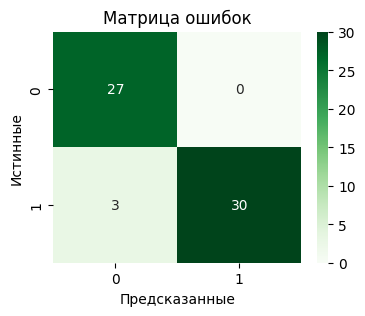

In [ ]:
X_train_torch = torch.tensor(X_train.values, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_torch = torch.tensor(X_test.values, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

class BinaryMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(X_train.shape[1], neurons_on_hidden[0]),
            nn.ReLU(),
            nn.Linear(neurons_on_hidden[0], neurons_on_hidden[1]),
            nn.ReLU(),
            nn.Linear(neurons_on_hidden[1], 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model = BinaryMLP()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = model(X_train_torch)
    loss = criterion(y_pred, y_train_torch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    probs = model(X_test_torch)
    y_pred = (probs > 0.5).int().view(-1).numpy()

custom_evaluation(y_test, y_pred)

## Вывод

Наиболее качественно работал классификатор на PyTorch, наиболее стабильный результат дает модель scikit learn так как можно явно указать seed (random_state)

# Fashion MNIST

## Задача

На базе классических нейронных сетей и библиотеки TensorFlow построить классификатор для данных из набора Fashion-MNIST

## Импорт библиотек

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

## Загрузка и предобработка данных

In [ ]:
# Загрузка данных
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Нормализация: пиксели от [0..255] → [0..1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Развёртка изображений в векторы (28×28 → 784)
x_train = x_train.reshape(x_train.shape[0], 28 * 28)
x_test = x_test.reshape(x_test.shape[0], 28 * 28)

print(f"Тренировочных образцов: {x_train.shape[0]}")
print(f"Тестовых образцов: {x_test.shape[0]}")
print(f"Размер входа: {x_train.shape[1]}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тренировочных образцов: 60000
Тестовых образцов: 10000
Размер входа: 784


## Построение модели

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dropout(0.2), # Регуляризация
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8379 - loss: 0.4509 - val_accuracy: 0.8592 - val_loss: 0.3809
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8492 - loss: 0.4121 - val_accuracy: 0.8692 - val_loss: 0.3639
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8589 - loss: 0.3778 - val_accuracy: 0.8663 - val_loss: 0.3565
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8707 - loss: 0.3568 - val_accuracy: 0.8735 - val_loss: 0.3392
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8720 - loss: 0.3518 - val_accuracy: 0.8678 - val_loss: 0.3499
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8802 - loss: 0.3288 - val_accuracy: 0.8715 - val_loss: 0.3427
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8829 - loss: 0.3190 - val_accuracy: 0.8777 - val_loss: 0.3297
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8832 - loss: 0.3

## Визуализация результатов

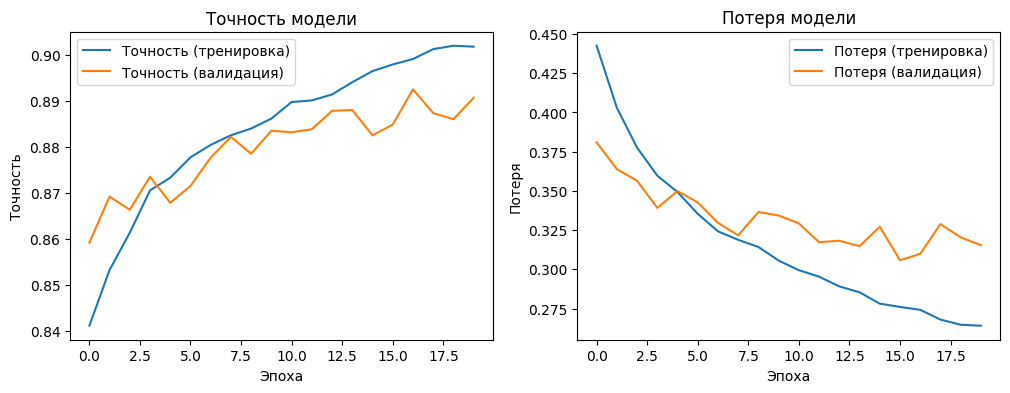

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точность (тренировка)')
plt.plot(history.history['val_accuracy'], label='Точность (валидация)')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Потеря (тренировка)')
plt.plot(history.history['val_loss'], label='Потеря (валидация)')
plt.title('Потеря модели')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.legend()

plt.show()

## Проверка модели

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


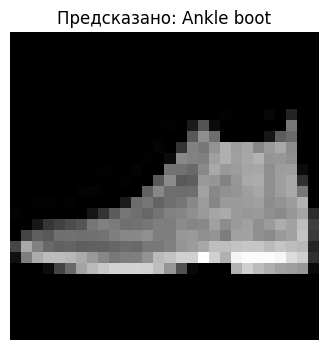

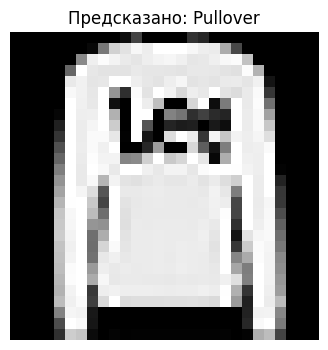

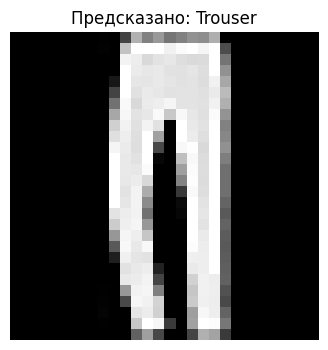

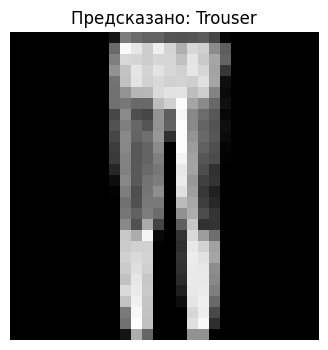

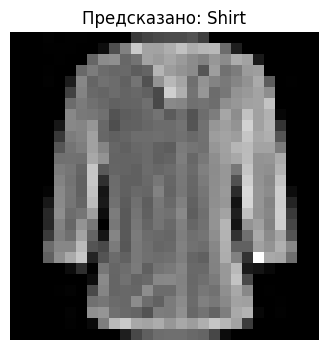

In [ ]:
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)

class_names = [
    'T‑shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

for i in range(5):
    plt.figure(figsize=(10, 4))
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Предсказано: {class_names[predicted_classes[i]]}")
    plt.axis('off')
    plt.show()